# Example of quantification of growth inhibition kinetics, permeabilization of IM and OM, medial axis and single-cell kymograph computation

__Steps__:
1. Download zip folder from BioStudies S-BIAD1823 for a given experiment/condition and extract the data. In this example, we will process data from 'CJW7845_CecA_1uM_rep1.zip'
2. Run 'import_processing_code.py' and curation functions 'post_processing_curation_functions.py' to obtain curated dataframes, as explained in '1_import_curation_single-cell_analysis.ipynb'
3. Import curated dataframes, run functions to obtain normalized growth rate, using weighted multi-derivative definition (see Methods for details), and permeabilization times, given fluorescence signal from mScarlet-I and mTagBFP2 channels
4. Plot IM, OM, permeabilization times over time, and times of growth arrest vs IM permeabilization
5. Compute medial axis example, and plot a single-cell kymograph

__Requirements on how to run__:
1. This notebook assumes the OmniSegger-processed extracted file data folder, here 'CJW7845_CecA_1uM_rep1', lives in the same folder as the notebook
2. The function libraries 'analysis_functions_library.py' and 'post_processing_curation_functions.py' are pulled from the repository folder '2_singlecell_microwells'

__Code underlying data and figures__:
- Single-cell data in PDMS microwells, strain CJW7845
- Figures 1-2, S2-S3, S5-S6

### 1. Compute normalized growth rate and IM, OM permeabilization times

Run time: < 10min

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
import os
from scipy import io
import skimage
import warnings
import re

"""
Import analysis functions library
"""
import sys
from pathlib import Path
sys.path.append(str(Path("../../2_singlecell_microwells/membrane_permeabilization").resolve()))
from get_permeabilization_time import *
from multi_scale_derivative import *

In [6]:
experiment_path = "CJW7845_CecA_1uM_rep1"     # -> extracted from CJW7845_CecA_1uM_rep1/
exp_name = experiment_path   # usual exp_name format is 'Strain_AMP_concentration_replicate#'
AMP_name = 'CecA_1uM'     # AMP name and concentration

# read fr_inj from the notes 
notes_file = next(Path(experiment_path).glob("notes_*.txt"))
print(notes_file.read_text())   # check when AMP was injected 'frame xx/yy'

Exp1) 250114, CJW7845 (0.2% arab, ampicillin overnight)

37degC, M9GluCAAT (0.2% Glu, 0.4% CAA)

FR = 60 s interval 

Sytox 50nM added with AMPs.

CellTak:
- 50uL, 5min, of CellTak. 3x MQ wash.
- 0.5uL, OD=0.1, 5min, in M9GluCAAT. Quick medium wash.

Treatments/pos:
xy01-03: CecA, 1uM--> injected at frame 27/28



In [38]:
import glob
'''--- Import curated dataframe from local output_2 ---'''
output_path = experiment_path + '/output_2'
df_files = sorted(glob.glob(output_path + '/*cell_features_df_first_curation*.pkl'))

df = pd.DataFrame()
for f in df_files:
    sub = pd.read_pickle(f)
    if len(sub) == 0:
        continue
    print('Loaded N=' + str(sub['cell_id'].nunique()) + ' cells from ' + os.path.basename(f))
    df = pd.concat([df, sub])

df['AMP'] = AMP_name

'''--- Channel info (single experiment) ---
mean_fluors order = [periplasmic mScarlet, cytoplasmic BFP, SYTOX]; peri_fluor = the periplasmic channel'''
ch_info_df = pd.DataFrame({
    'AMP':        [AMP_name] * df['rep'].nunique(),
    'rep':        list(df['rep'].unique()),
    'mean_fluors':[["mean_fluor1", "mean_fluor2", "mean_fluor3"]] * df['rep'].nunique(),
    'peri_fluor': ['fluor1'] * df['rep'].nunique(),
})

'''--- Keep trajectories >= 40 frames ---'''
df = df.groupby('cell_id').filter(lambda c: len(c) >= 40)

'''--- Weighted multi-scale derivative: growth-arrest detection ---'''
df = apply_weighted_derivative_detection(
    df,
    window_sizes=[3, 5, 7, 9, 11],
    threshold_strict=0,
    threshold_stable=0.005,
    threshold_strict_2=0.01,
    threshold_stable_2=0.012,
    stable_window=30,
    polyorder=2,
    weight_mode=[5, 8, 10, 8, 5],
    normalized=True,
)

'''--- Permeabilization timing (IM/OM/SYTOX) ---'''
tp_df = get_permeabilization_time(df, ch_info_df, thr_IM=-30, w_Sy=10)

Loaded N=23 cells from xy01_11_CecA_1uM_250114_1_4_CJW7845_cell_features_df_first_curation.pkl
Loaded N=15 cells from xy02_11_CecA_1uM_250114_1_4_CJW7845_cell_features_df_first_curation.pkl
Loaded N=12 cells from xy03_11_CecA_1uM_250114_1_4_CJW7845_cell_features_df_first_curation.pkl


__Plot cumulative distribution of IM permeabilization times__

In [39]:
def plot_cum_perm(ax, tp_df, amp_list, color_dict, membrane="IM", t_end=241, title=""):
    """
    Cumulative permeabilisation on *ax*.
    Fraction = permeabilised events / total tracked cells.
    """
    sub = (
        tp_df[tp_df["AMP"].isin(amp_list)]
        .dropna(subset=["t_gr_stop"])
        .copy()
    )
    sub["abbr"] = sub["AMP"].apply(amp_abbr)

    # build hue_order from the REQUESTED list, not the filtered frame,
    # so zero-event peptides (dropped upstream) still appear
    hue_order = sorted({amp_abbr(a) for a in amp_list})

    for label in hue_order:
        grp         = sub[sub["abbr"] == label]
        total_n     = len(grp)
        event_times = np.sort(grp[f'tp_{membrane}_offset'].dropna().to_numpy())
        k           = len(event_times)
        color       = color_dict.get(label, "grey")

        if total_n == 0 or k == 0:
            # no tracked cells or no events → flat line at zero, still labelled
            ax.step([0, t_end], [0, 0], where="post",
                    color=color, lw=3, label=label)
        else:
            y      = np.arange(1, k + 1) / total_n
            x_step = np.r_[0, event_times, t_end]
            y_step = np.r_[0, y, y[-1]]
            ax.step(x_step, y_step, where="post",
                    color=color, lw=2, label=label)

    ax.set_xlim(-20, t_end)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time after AMP addition (min)", fontsize=12)
    ax.set_ylabel(f"Fraction {membrane}-permeabilised cells", fontsize=12)
    if title:
        ax.set_title(title, fontsize=13, fontweight="bold")

    handles, labels_leg = ax.get_legend_handles_labels()
    ax.legend(
        handles, labels_leg,
        title="AMP",
        bbox_to_anchor=(1.05, 1), loc="upper left",
        borderaxespad=0.0, fontsize=9,
    )

color_dict = {
    'HBD-3':  '#FF8FB1',                              # pink
    'Indo':   '#E63946',                              # red
    'LL-37':  '#FDB97D',                              # light orange
    'Mag2':   '#E8751A',                              # dark/intense orange
    'Mltt':   '#C8A2E0',                              # light purple
    'PG-1':   '#5E2A84',                              # dark purple
    'PR-39':  '#FFDF00',                              # gold/yellow
    'Rif':    '#8B5A2B',                              # brown
    'Spect':  '#A678C7',                              # lighter purple than PG-1
    'Tac1':   '#B0B0B0',                              # grey
    'Tur1A':  sns.color_palette("tab10", 10)[-2],     # olive/yellow-green
    'Tur1B':  sns.color_palette("tab10", 10)[-1],     # cyan-blue
    'DJK-5': sns.color_palette("rocket")[0],
    'TM1': sns.color_palette("rocket")[1],
    'TM5': sns.color_palette("rocket")[2]
}
# Fallback palette for peptides not in canonical map
custom_palette_cum = list(sns.color_palette("Paired", 12))
custom_palette_cum += [sns.color_palette("tab10", 10)[4], sns.color_palette("tab10", 10)[9]]
custom_palette_cum += [sns.color_palette("tab20", 20)[16], sns.color_palette("tab20", 20)[18]]

AMP_TOKEN_TO_ABBR = {
    # Natural peptides
    "LL-37":    "LL-37",
    "CecA":     "CecA",
    "Tachy":    "Tac1",    
    "Tac1":     "Tac1",
    "Mag2":     "Mag2",
    "HBD3":     "HBD-3",    
    "HBD-3":    "HBD-3",
    "Indo":     "Indo",
    "PR-39":    "PR-39",
    "Bac7":     "Bac7",
    "DJK-5":    "DJK-5",
    "Mltt":     "Mltt",
    "Melittin": "Mltt",      
    "Tur1A":    "Tur1A",
    "Tur1B":    "Tur1B",
    "CamBac":   "CamBac",
    "CRAMP":    "CRAMP",
    "PG-1":     "PG-1",
    # Synthetic
    "TM1":      "TM1",
    "TM4":      "TM4",
    "TM5":      "TM5",
    "IDR-1018": "IDR-1018",
    # Antibiotics
    "Spect":    "Spect",
    "Rif":      "Rif",
}

def amp_abbr(amp_string: str) -> str:
    parts = amp_string.split("_")
    token = parts[1] if len(parts) >= 2 else amp_string
    return AMP_TOKEN_TO_ABBR.get(token, token)


In [40]:
tp_df_cum_IM = tp_df.dropna(subset=['t_gr_stop','tp_IM'])
AMP_2xMIC_list = ['CecA_1uM']

__Cumulative IM perm. distribution for CecA-treated CJW7845 cells for 1 replicate__

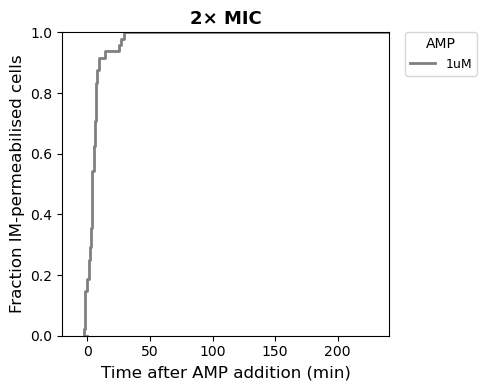

In [41]:
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
plot_cum_perm(axes, tp_df_cum_IM, AMP_2xMIC_list, color_dict, t_end=241, title='2X MIC')
plt.tight_layout()
plt.show()

In [45]:
tp_df_cum_OM = tp_df_cum_IM.dropna(subset=['tp_IM'])
AMP_2xMIC_list = ['CecA_1uM']

__Cumulative OM perm. distribution for CecA-treated CJW7845 cells for 1 replicate__

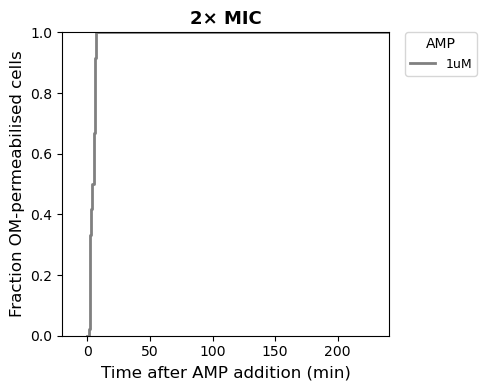

In [46]:
fig, axes = plt.subplots(1, 1, figsize=(5, 4))
plot_cum_perm(axes, tp_df_cum_OM, AMP_2xMIC_list, color_dict, membrane = "OM", t_end=241, title='2X MIC')
plt.tight_layout()
plt.show()


__Plot growth arrest vs IM permeabilization time__

In [42]:
'''plot diagonal line y=x'''
def plot_x_equals_y(**kwargs):
    ax = plt.gca()
    ax.plot([min_val, max_val], [min_val, max_val], '--', color='black', lw=1)

# Define a simple scatter function that uses transparency.
def scatter_transparent(data, x, y, color='black', alpha = 0.15, **kwargs):
    # Extract the data
    x_data = data[x].values
    y_data = data[y].values
    # Use the custom colormap at a fixed mid-range value (e.g., 0.5)
    # color = custom_colormap(0.5)
    # Plot the points with no face color, transparent edges, and a constant marker size.
    plt.scatter(x_data, y_data, s=60,
                facecolors='none', 
                # edgecolors=color, 
                edgecolors=color, 
                alpha=alpha,  # low alpha so overlapping points appear darker
                linewidths=1.5,
                marker='o',
                **kwargs)


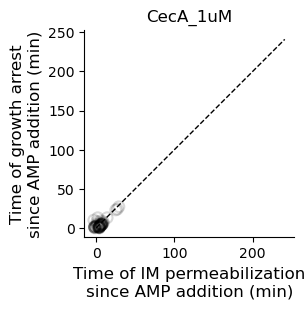

In [47]:

'''Scatterplot gr_arr vs IM_perm'''
AMP_2xMIC_list = ['CecA_1uM']
amp_order = AMP_2xMIC_list
x_var = 'tp_IM_offset'
y_var = 't_gr_stop_offset'
df_clean = tp_df.dropna(subset=[x_var, y_var])
df_clean = df_clean[np.isin(df_clean['AMP'], AMP_2xMIC_list)]

# Calculate global min and max for plotting the diagonal line y=x
min_val = 0
max_val = 241

# Create a FacetGrid to display one plot per AMP group.
g = sns.FacetGrid(
    df_clean,
    col="AMP",
    col_wrap=7,
    col_order=amp_order,  
    height=3,
    aspect=1,
    # hue = 'MIC_fold',
    sharex=True,
    sharey=True,
)
g.map_dataframe(scatter_transparent, x=x_var, y=y_var, color = 'black')
g.map(plot_x_equals_y)
for ax in g.axes.flat:
    ax.set_aspect('equal')
g.set_axis_labels("Time of IM permeabilization\nsince AMP addition (min)",
                  "Time of growth arrest\nsince AMP addition (min)", fontsize=12)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    amp_name = ax.get_title().split()[0]
    ax.set_title(f"{amp_name}")


__Plot IM perm. time vs OM perm. time__

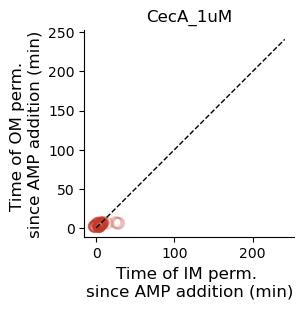

In [48]:
'''Scatterplot gr_arr vs IM_perm'''
AMP_2xMIC_list = ['CecA_1uM']
amp_order = AMP_2xMIC_list
x_var = 'tp_IM_offset'
y_var = 'tp_OM_offset'
df_clean = tp_df.dropna(subset=[x_var, y_var])
df_clean = df_clean[np.isin(df_clean['AMP'], AMP_2xMIC_list)]

# Calculate global min and max for plotting the diagonal line y=x
min_val = 0
max_val = 241

# Create a FacetGrid to display one plot per AMP group.
g = sns.FacetGrid(
    df_clean,
    col="AMP",
    col_wrap=7,
    col_order=amp_order,  
    height=3,
    aspect=1,
    # hue = 'MIC_fold',
    sharex=True,
    sharey=True,
)
g.map_dataframe(scatter_transparent, x=x_var, y=y_var, color='#C0392B',alpha = 0.25)
g.map(plot_x_equals_y)
for ax in g.axes.flat:
    ax.set_aspect('equal')
g.set_axis_labels("Time of IM perm. \nsince AMP addition (min)",
                  "Time of OM perm. \nsince AMP addition (min)", fontsize=12)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    amp_name = ax.get_title().split()[0]
    ax.set_title(f"{amp_name}")


__Plot residuals from diagonal (growth arrest vs IM perm.)__

In [50]:

def bootstrap_mean_ci(data, n_bootstrap=1000, ci=95):
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return np.mean(data), lower, upper


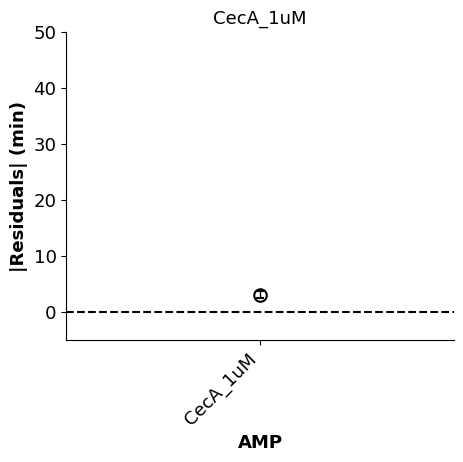

In [58]:
'''plot residuals growth arrest vs IM perm'''
AMP_2xMIC_list = ['CecA_1uM']
amp_order = AMP_2xMIC_list

amp_panels = {
    '2X MIC': AMP_2xMIC_list
}

x_var, y_var = 'tp_IM_offset', 't_gr_stop_offset'

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
# filter and compute residuals
df = tp_df.dropna(subset=[x_var, y_var]).copy()
df = df[df['AMP'].isin(AMP_2xMIC_list)].copy()
df['resid'] = np.abs(df[x_var] - df[y_var])

# bootstrap mean + 95% CI for each AMP
amps, means, lowers, uppers = [], [], [], []
for amp in AMP_2xMIC_list:
    vals = df.loc[df['AMP'] == amp, 'resid'].values
    if len(vals) < 2:
        continue
    m, lo, hi = bootstrap_mean_ci(vals, n_bootstrap=1000, ci=95)
    amps.append(amp)
    means.append(m)
    lowers.append(m - lo)
    uppers.append(hi - m)

x = np.arange(len(amps))

ax.errorbar(
    x, means,
    yerr=[lowers, uppers],
    fmt='o',
    markersize=9,
    markerfacecolor='none',   # empty circles
    markeredgecolor='black',
    markeredgewidth=1.5,
    ecolor='black',
    elinewidth=1,
    capsize=3,
    linestyle='none'
)

ax.set_title('CecA_1uM', fontsize=13)
ax.set_xlabel("AMP", fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(amps, rotation=45, ha='right', fontsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.set_ylim(-5,50)
ax.axhline(y=0, linestyle = '--', c= 'k')

ax.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

if i == 0:
    ax.set_ylabel("|Residuals| (min)", fontsize=13, fontweight='bold')
else:
    ax.set_ylabel("")


plt.show()


__To plot other quantities:__
1. Delay between start of time of growth inhibition and growth arrest (Figure S2C and S6E) use:

```tp_df['t_gr_arrest_speed'] = tp_df['t_gr_stop'] - tp_df['t_gr_stop_early']```

2. Time of growth arrest since AMP addition (Figure S6A) use: 

```tp_df['t_gr_stop_offset'] = tp_df['t_gr_stop'] - tp_df['fr_inj']*fr```

### Medial axis computation

Run time ~ 1s per frame per cell

In [1]:
from scipy.signal import lfiltic, lfilter
import skimage
from scipy import io
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import math
import torch
import keyboard
import time
import cupy as cp
import json
import pickle
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import splprep, splev, splrep, interp1d, UnivariateSpline, BSpline
from scipy.signal import lfilter, savgol_filter
from scipy.stats import spearmanr
from skimage import graph, morphology, measure
import imageio.v3 as iio
from scipy.ndimage import gaussian_filter, gaussian_filter1d, binary_fill_holes, binary_closing, binary_opening
from scipy import ndimage
from PIL import Image as im
from skimage.morphology import skeletonize
from skimage.filters import threshold_otsu, threshold_local
from skimage.segmentation import find_boundaries
from skimage import measure, morphology
from numpy.lib.stride_tricks import as_strided
import warnings
from scipy.ndimage import distance_transform_edt
from skimage.feature import peak_local_max
from skimage.morphology import disk
from scipy.signal import find_peaks
warnings.filterwarnings('ignore')
import gc

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA Available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())

cp.cuda.Device(0).use()

"""
Import analysis functions library
"""
import sys
from pathlib import Path
sys.path.append(str(Path("../../2_singlecell_microwells").resolve()))
from analysis_functions_library import *

'''Global variables'''
fr = 1    # [min] time between frame
px_size = 0.065841  # um/px   (pixel size, 100x)

Device: cuda
CUDA Available: True
Number of GPUs: 2


In [2]:
experiment_path = "CJW7845_CecA_1uM_rep1"     # -> extracted from CJW7845_CecA_1uM_rep1/
AMP_name = 'CecA_1uM'     # AMP name and concentration

# read fr_inj from the notes 
notes_file = next(Path(experiment_path).glob("notes_*.txt"))
print(notes_file.read_text())   # check when AMP was injected 'frame xx/yy'

Exp1) 250114, CJW7845 (0.2% arab, ampicillin overnight)

37degC, M9GluCAAT (0.2% Glu, 0.4% CAA)

FR = 60 s interval 

Sytox 50nM added with AMPs.

CellTak:
- 50uL, 5min, of CellTak. 3x MQ wash.
- 0.5uL, OD=0.1, 5min, in M9GluCAAT. Quick medium wash.

Treatments/pos:
xy01-03: CecA, 1uM--> injected at frame 27/28



In [3]:
aug = 20
fr = 1    # [min] time between frame
px_size = 0.065841  # um/px   (pixel size in alpha scope, 100x)
save = False
overwrite = False
plot = True
ch_list = ['phase', 'fluor1', 'fluor2','fluor3']
ch_fluor_list = [s for s in ch_list if 'fluor' in s]
exp_name = '11_CecA_1uM_250114_1_4_CJW7845'

In [3]:
import glob
'''--- Import curated dataframe from local output_2 ---'''
output_path = experiment_path + '/output_2'
df_files = sorted(glob.glob(output_path + '/*cell_features_df_first_curation*.pkl'))

df = pd.DataFrame()
for f in df_files:
    sub = pd.read_pickle(f)
    if len(sub) == 0:
        continue
    print('Loaded N=' + str(sub['cell_id'].nunique()) + ' cells from ' + os.path.basename(f))
    df = pd.concat([df, sub])

df['AMP'] = AMP_name

Loaded N=23 cells from xy01_11_CecA_1uM_250114_1_4_CJW7845_cell_features_df_first_curation.pkl
Loaded N=15 cells from xy02_11_CecA_1uM_250114_1_4_CJW7845_cell_features_df_first_curation.pkl
Loaded N=12 cells from xy03_11_CecA_1uM_250114_1_4_CJW7845_cell_features_df_first_curation.pkl


No medial axis already computed
Importing channels dictionary for 11_CecA_1uM_250114_1_4_CJW7845 at position xy01...
Importing dataframe 11_CecA_1uM_250114_1_4_CJW7845 at position xy01...
..Computing medial axis for cells at position xy01 for experiment 11_CecA_1uM_250114_1_4_CJW7845
cell0000006_xy01_11_CecA_1uM_250114_1_4_CJW7845


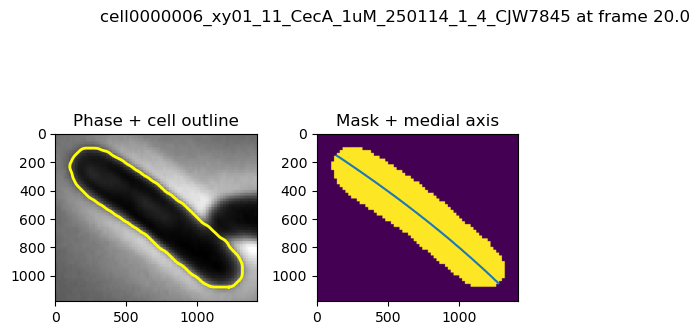

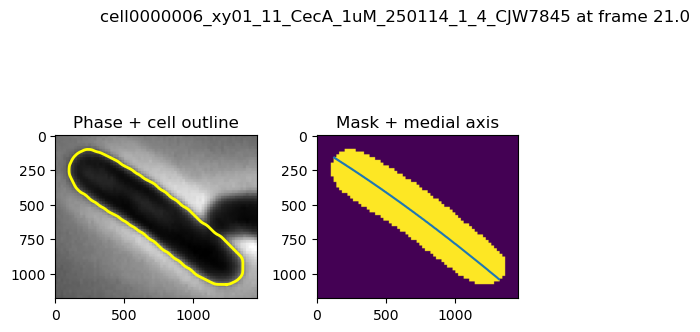

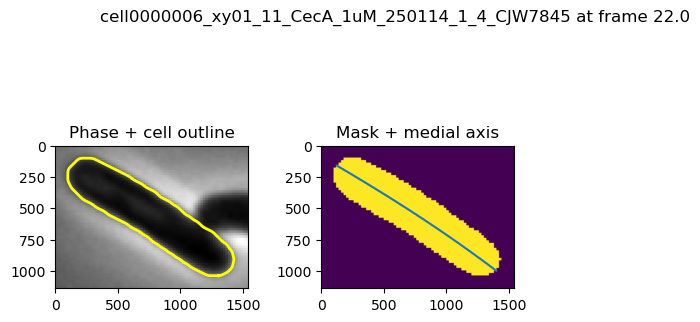

No medial axis already computed
Importing channels dictionary for 11_CecA_1uM_250114_1_4_CJW7845 at position xy02...
Importing dataframe 11_CecA_1uM_250114_1_4_CJW7845 at position xy02...
..Computing medial axis for cells at position xy02 for experiment 11_CecA_1uM_250114_1_4_CJW7845
cell0000008_xy02_11_CecA_1uM_250114_1_4_CJW7845


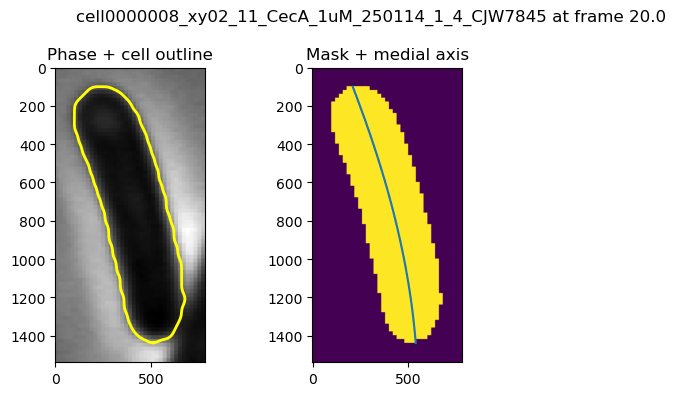

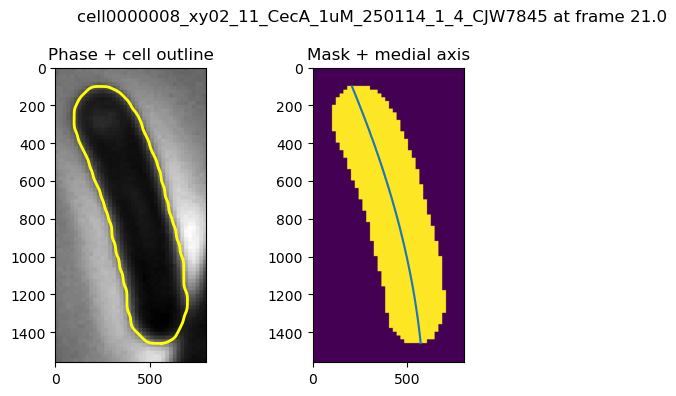

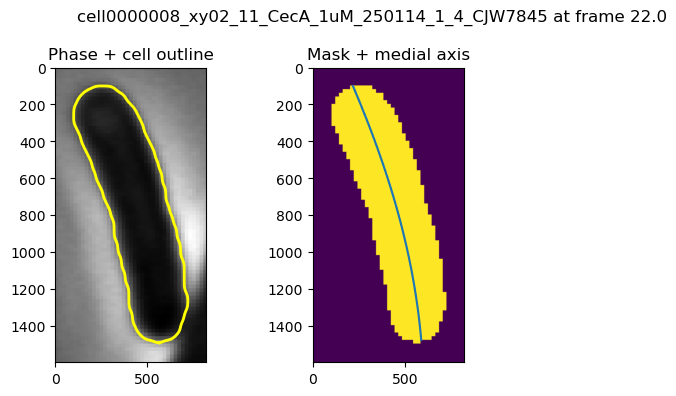

No medial axis already computed
Importing channels dictionary for 11_CecA_1uM_250114_1_4_CJW7845 at position xy03...
Importing dataframe 11_CecA_1uM_250114_1_4_CJW7845 at position xy03...
..Computing medial axis for cells at position xy03 for experiment 11_CecA_1uM_250114_1_4_CJW7845
cell0000002_xy03_11_CecA_1uM_250114_1_4_CJW7845


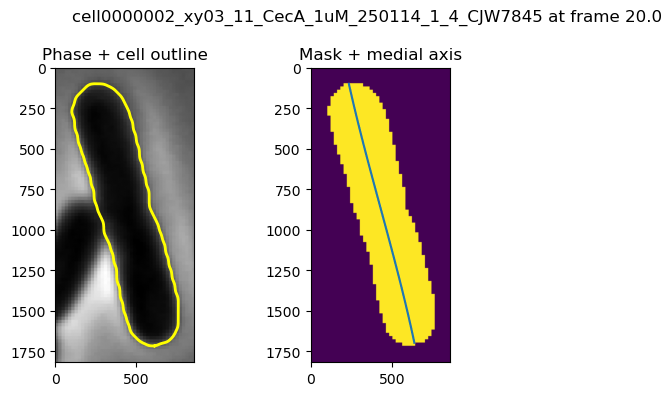

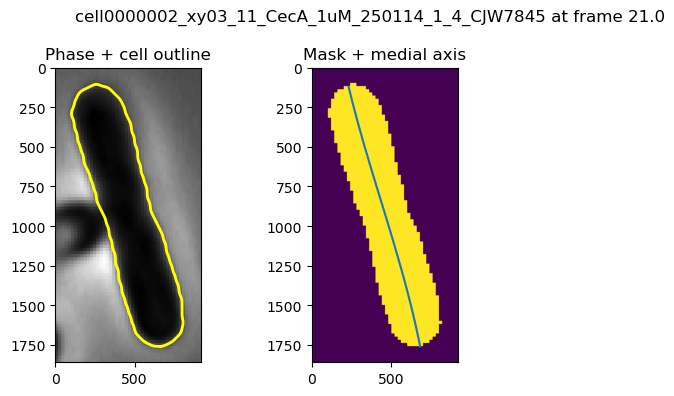

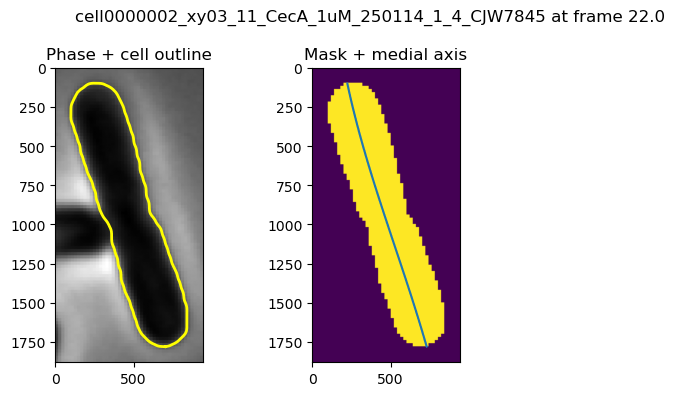

In [14]:
'''Medial-axis computation — single experiment, loop over positions only'''
rep = 'rep_1'                                          # single replicate for this demo
pos_list = ['xy' + s for s in df['xy'].unique().tolist()]

for pos in pos_list:
    folder_path = experiment_path + '/' + pos           # path to position
    cells_path = folder_path + "/cell"
    mask_path = folder_path + '/masks'
    phase_path = folder_path + '/phase'
    output_path = experiment_path + '/output'
    output_2_path = experiment_path + '/output_2'
    output_medial_path = experiment_path + '/output_medial'

    if os.path.exists(output_medial_path) and not overwrite:
        medial_list = os.listdir(output_medial_path)
        if len([s for s in medial_list if pos in s]) > 0:
            medial_axis_df_name = [s for s in medial_list if pos in s and 'medial' in s][0]
            if len(medial_axis_df_name) > 0:
                print('Medial axes already computed for ' + pos + ', ' + exp_name)
                continue
    else:
        print('No medial axis already computed')
        medial_list = []
    if os.path.exists(output_path) and os.path.exists(output_2_path):
        if len([s for s in os.listdir(output_path) if pos in s]) == 0:
            continue

    if os.path.exists(cells_path):
        cells_list = os.listdir(cells_path)
    else:
        continue
    if len(cells_list) == 0:
        continue

    masks_list = os.listdir(mask_path)
    phase_list = os.listdir(phase_path)

    '''Import json and pickle files'''
    print('Importing channels dictionary for ' + exp_name + ' at position ' + pos + '...')
    with open(output_path + '/' + pos + '_' + exp_name + '_cell_ch_bkg_sub.pkl', 'rb') as pickle_file:
        cell_ch_dict = pickle.load(pickle_file)

    df_list = os.listdir(output_2_path)
    df_name = [s for s in df_list if 'first_curation' in s and pos in s]
    if len(df_name) == 0:
        continue
    print('Importing dataframe ' + exp_name + ' at position ' + pos + '...')

    
    with open(output_2_path + '/' + df_name[0], 'rb') as f:
        df_temp = pickle.load(f)
    cells_list = list(df_temp['cell_id'].unique())
    print('..Computing medial axis for cells at position ' + pos + ' for experiment ' + exp_name)
    medial_axis_df = pd.DataFrame()
    medial_proj_df = pd.DataFrame()
    for cell in cells_list[:1]:   # remove [] to analyse the whole cell list 
        print(cell)
        cell_df = df_temp[df_temp['cell_id'] == cell]
        frame_list = cell_df['frame'].to_list()
        i_prev = None  
        for i in frame_list[19:22]:    # remove [] to analyse the whole trajectory 

            no_peak = False

            cell_ch = cell_ch_dict[cell, i][0]
            cropped_mask = cell_ch['mask']
            if np.size(cropped_mask) > 50000:
                continue
            cell_stack_temp = cell_ch_dict[cell, i][1]
            A, rcm, r_off, angle, x1, x2, y1, y2, edge_flag = get_cell_coordinates(cell_stack_temp)
            start = time.time()
            medial_axis, cell_mask, bad_cell_flag = get_medial_axis_cp(cropped_mask, r_off, rcm, angle, show=False, aug=20)
            end = time.time()
            if bad_cell_flag:
                bad_cell_flag = False
                continue
            if i_prev is not None:
                prev_medial_axis_df = medial_axis_df[(medial_axis_df['cell_id'] == cell) & (medial_axis_df['frame'] == i_prev)]
                prev_medial_axis = np.column_stack([prev_medial_axis_df['medial_axis_y'], prev_medial_axis_df['medial_axis_x']])
                medial_axis = flip_medial_axis(medial_axis, prev_medial_axis, show=False)

            medial_dist, medial_abs = calculate_euclidean_distance(
                medial_axis, pixel_size=px_size, aug=aug)

            ## Local thickness parameter extraction
            smoothed_mask = gaussian_filter(cell_mask.get().astype(float), sigma=20) > 0.5
            distance_map = distance_transform_edt(smoothed_mask)
            local_thickness = distance_map[medial_axis[:, 0], medial_axis[:, 1]]
            local_thickness_norm = local_thickness / np.max(local_thickness)
            window_length = closest_odd(len(local_thickness) / 7)
            polyorder = 3
            smoothed_thickness_norm = savgol_filter(local_thickness_norm, window_length=window_length, polyorder=polyorder)
            medial_abs_norm = np.insert(medial_abs, 0, 0) / np.max(np.insert(medial_abs, 0, 0))
            inverted_thickness = -smoothed_thickness_norm
            idx_sub = np.where((medial_abs_norm > 0.3) & (medial_abs_norm < 0.7))

            medial_abs_norm_roi = medial_abs_norm[idx_sub]

            idx_baseline = np.where((medial_abs_norm > 0.3) & (medial_abs_norm < 0.4) | (medial_abs_norm > 0.6) & (medial_abs_norm < 0.7))
            baseline = np.median(inverted_thickness[idx_baseline])
            inverted_thickness_norm_roi = inverted_thickness[idx_sub] + abs(baseline)

            width = np.median(local_thickness[idx_baseline]) * 2
            width_um = px_size * (width / aug)

            peaks_indices, properties = find_peaks(inverted_thickness_norm_roi)
            if len(peaks_indices) > 0:
                mid_idx = peaks_indices[np.argmax(inverted_thickness_norm_roi[peaks_indices])]
            else:
                if len(np.where(medial_abs_norm_roi > 0.5)[0]) > 0:
                    mid_idx = np.where(medial_abs_norm_roi > 0.5)[0][0]
                    no_peak = True
                else:
                    mid_idx = None
            if not mid_idx:
                continue

            if plot:
                cropped_phase = tile_array(cell_ch['phase'], 20, 20)
                contours = measure.find_contours(smoothed_mask, level=0.5)

                fig = plt.figure(figsize=(8,4))
                plt.suptitle(cell + ' at frame ' + str(i))

                ax1 = fig.add_subplot(1, 3, 1)
                plt.imshow(cropped_phase, cmap  = 'grey')
                if contours != False:
                    for contour in contours:
                        ax1.plot(contour[:, 1], contour[:, 0], linewidth=2, color='yellow')
                ax1.set_title('Phase + cell outline')

                ax2 = fig.add_subplot(1, 3, 2)
                plt.imshow(cell_mask.get())
                plt.plot(medial_axis[:, 1], medial_axis[:, 0])
                ax2.set_title('Mask + medial axis')

                plt.tight_layout()
                plt.show()

            medial_axis_cell_df = pd.DataFrame()
            medial_axis_cell_df['medial_axis_x'] = medial_axis[:, 1]
            medial_axis_cell_df['medial_axis_y'] = medial_axis[:, 0]
            medial_axis_cell_df['medial_coord'] = list(zip(medial_axis[:, 0], medial_axis[:, 1]))
            medial_axis_cell_df['length_um'] = np.insert(medial_abs, 0, 0)
            medial_axis_cell_df['frame'] = i
            medial_axis_cell_df['cell_id'] = cell
            medial_axis_cell_df['exp'] = exp_name
            medial_axis_cell_df['rep'] = rep
            medial_axis_cell_df['local_thickness'] = local_thickness
            medial_axis_cell_df['width_um'] = width_um
            medial_axis_cell_df['width'] = width
            medial_axis_cell_df['sept_medial_idx'] = mid_idx
            if no_peak:
                print('No peak found at frame ' + str(i) + ' for cell ' + cell)
                medial_axis_cell_df['sept_score'] = 0
            else:
                medial_axis_cell_df['sept_score'] = inverted_thickness_norm_roi[mid_idx]

            medial_axis_df = pd.concat([medial_axis_df, medial_axis_cell_df])

            medial_proj_cell_df = pd.DataFrame()
            for k in range(len(ch_list)):
                ch = ch_list[k]
                if k == 0:
                    medial_proj_cell_df, _, _, _ = get_1D_proj_medial(cell_ch[ch], cropped_mask, medial_axis)
                    medial_proj_cell_df.rename(columns={'px_int': 'px_int_' + ch}, inplace=True)
                    medial_proj_cell_df.drop(columns=['OriginalIndex'], inplace=True)
                else:
                    medial_proj_ch_df, _, _, _ = get_1D_proj_medial(cell_ch[ch], cropped_mask, medial_axis)
                    medial_proj_cell_df['px_int_' + ch] = medial_proj_ch_df['px_int']

            medial_proj_cell_df['frame'] = i
            medial_proj_cell_df['cell_id'] = cell
            medial_proj_cell_df['exp'] = exp_name
            medial_proj_cell_df['rep'] = rep

            medial_proj_df = pd.concat([medial_proj_df, medial_proj_cell_df])

            i_prev = i

    if save:
        medial_df_basename = exp_name + '_' + pos + '_medial_axis_df'
        if not os.path.exists(output_medial_path):
            os.mkdir(output_medial_path)
        with open(output_medial_path + '/' + medial_df_basename + '.pkl', 'wb') as pickle_file:
            pickle.dump(medial_axis_df, pickle_file)
        print(medial_df_basename + ' was save to dataframe')

        medial_proj_df_basename = exp_name + '_' + pos + '_medial_proj_df'
        with open(output_medial_path + '/' + medial_proj_df_basename + '.pkl', 'wb') as pickle_file:
            pickle.dump(medial_proj_df, pickle_file)
        print(medial_proj_df_basename + ' was save to dataframe')

    del df_temp
    gc.collect()

### Using computed medial axis, extract arc length and add to existing cell features dataframe

Run time = few seconds per cell

In [16]:
'''Cell-length step — merge medial-axis arc length into the cell dataframe.
Follows the medial-axis computation: reads the per-position *_medial_proj_df.pkl from output_medial,
computes arc length per frame, and saves *_cell_features_df_cell_length.pkl to output_2.'''

for pos in pos_list:
    output_2_path = experiment_path + '/output_2'
    output_medial_path = experiment_path + '/output_medial'

    # curated cell-features dataframe for this position
    df_name = [s for s in os.listdir(output_2_path) if 'first_curation' in s and pos in s]
    if len(df_name) == 0:
        continue
    with open(output_2_path + '/' + df_name[0], 'rb') as f:
        df_temp = pickle.load(f)

    # medial-axis projection dataframe from the previous step
    proj_name = [s for s in os.listdir(output_medial_path) if 'medial_proj_df' in s and pos in s]
    if len(proj_name) == 0:
        print('No medial_proj_df for ' + pos + ' — run the medial-axis step first')
        continue
    with open(output_medial_path + '/' + proj_name[0], 'rb') as f:
        medial_proj_df = pickle.load(f)

    print('..Computing cell length at position ' + pos + ' for experiment ' + exp_name)
    df_new = pd.DataFrame()
    for cell in df_temp['cell_id'].unique()[1:5]:   # compute for all cells --> remove [1:5]
        cell_df = df_temp[df_temp['cell_id'] == cell]
        medial_proj_cell_df = medial_proj_df[medial_proj_df['cell_id'] == cell]
        if len(medial_proj_cell_df) == 0:
            continue
        for i in cell_df['frame'].to_list():
            medial_proj_frame_df = medial_proj_cell_df[medial_proj_cell_df['frame'] == i]
            if len(medial_proj_frame_df) == 0:
                continue                                    # frame has no medial axis -> skip it
            medial_proj_frame_df = medial_proj_frame_df.drop_duplicates(subset=['m_proj_coord'])
            medial_axis_frame = np.vstack([medial_proj_frame_df['m_proj_x'], medial_proj_frame_df['m_proj_y']]).T
            medial_dist, medial_abs = calculate_euclidean_distance(medial_axis_frame, pixel_size=px_size, aug=aug)

            frame_df_temp = cell_df[cell_df['frame'] == i].copy()   # .copy() -> no SettingWithCopyWarning
            frame_df_temp['cell_length'] = medial_abs[-1]           # arc length = last cumulative distance
            df_new = pd.concat([df_new, frame_df_temp])

    if save and len(df_new) > 0:
        df_basename = pos + '_' + exp_name + '_cell_features_df_cell_length'
        with open(output_2_path + '/' + df_basename + '.pkl', 'wb') as pickle_file:
            pickle.dump(df_new, pickle_file)
        print(df_basename + ' was saved to dataframe')

    del df_temp, medial_proj_df
    gc.collect()

..Computing cell length at position xy01 for experiment 11_CecA_1uM_250114_1_4_CJW7845
..Computing cell length at position xy02 for experiment 11_CecA_1uM_250114_1_4_CJW7845
..Computing cell length at position xy03 for experiment 11_CecA_1uM_250114_1_4_CJW7845


### Using computed mean intensity projection dataframe, compute single-cell kymographs

In [4]:
'''Kymograph step — 1D mean-intensity projections along the medial axis → per-cell kymographs.
Follows the medial-axis computation: loads the saved *_medial_proj_df.pkl from output_medial,
renames the generic fluor channels to the fluorophore names the kymograph code expects,
computes the binned 1D axial projections, then builds & plots per-cell kymographs.'''

import sys
from pathlib import Path
sys.path.append(str(Path("../../2_singlecell_microwells/kymographs").resolve()))
from kymograph_single_cell import compute_1D_mean_int_proj_single_cell, build_export_kymographs_single_cell

# calculate_averages_1D reads px_int_mScarlet/bfp/sytox_green, and the plotting keys on
# ch_info_list = ['mScarlet','bfp','sytox_green']. Map your fluor1/2/3 to those names.
ch_rename = {
    'px_int_fluor1': 'px_int_sytox_green',
    'px_int_fluor2': 'px_int_mScarlet',
    'px_int_fluor3': 'px_int_bfp',
}
n_cells = 3                                  # how many cells to demo

# --- load medial projections saved by the medial-axis step (all positions) ---
output_medial_path = experiment_path + '/output_medial'
proj_files = [s for s in os.listdir(output_medial_path) if 'medial_proj_df' in s]
medial_proj_df = pd.DataFrame()
for f in proj_files:
    with open(output_medial_path + '/' + f, 'rb') as fh:
        medial_proj_df = pd.concat([medial_proj_df, pickle.load(fh)])
medial_proj_df = medial_proj_df.rename(columns=ch_rename)

# --- keep just a few cells for the demo ---
demo_cells = medial_proj_df['cell_id'].unique()[:n_cells]
medial_proj_df = medial_proj_df[medial_proj_df['cell_id'].isin(demo_cells)]
print('Demo cells:', list(demo_cells))

# --- compute + save 1D axial mean projections (writes to experiment_path/<rep>/output_1D_mean_proj) ---
compute_1D_mean_int_proj_single_cell(
    medial_proj_df, save=True, return_=False,
    experiment_path=experiment_path, exp_name=exp_name,
    px_thr=4, aug=20, bin_size_l=0.065)


Demo cells: ['cell0000006_xy01_11_CecA_1uM_250114_1_4_CJW7845', 'cell0000007_xy01_11_CecA_1uM_250114_1_4_CJW7845', 'cell0000013_xy01_11_CecA_1uM_250114_1_4_CJW7845']
Computing the mean 1D intensity proj for cell cell0000006_xy01_11_CecA_1uM_250114_1_4_CJW7845
Computing the mean 1D intensity proj for cell cell0000007_xy01_11_CecA_1uM_250114_1_4_CJW7845
Computing the mean 1D intensity proj for cell cell0000013_xy01_11_CecA_1uM_250114_1_4_CJW7845
Dataframe of 1D axial mean projections were saved in CJW7845_CecA_1uM_rep1/output_1D_mean_proj


cell0000006_xy01_11_CecA_1uM_250114_1_4_CJW7845
Exporting kymo for cell0000006_xy01_11_CecA_1uM_250114_1_4_CJW7845


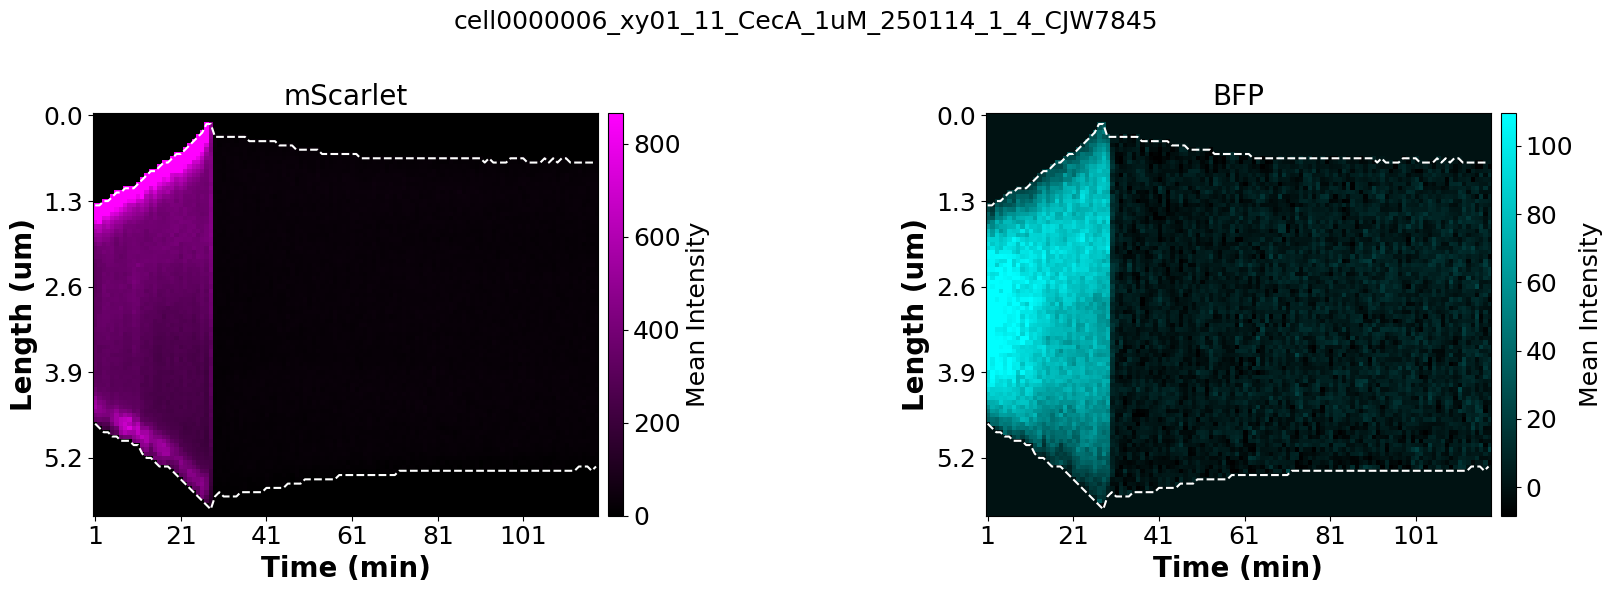

cell0000007_xy01_11_CecA_1uM_250114_1_4_CJW7845
Exporting kymo for cell0000007_xy01_11_CecA_1uM_250114_1_4_CJW7845


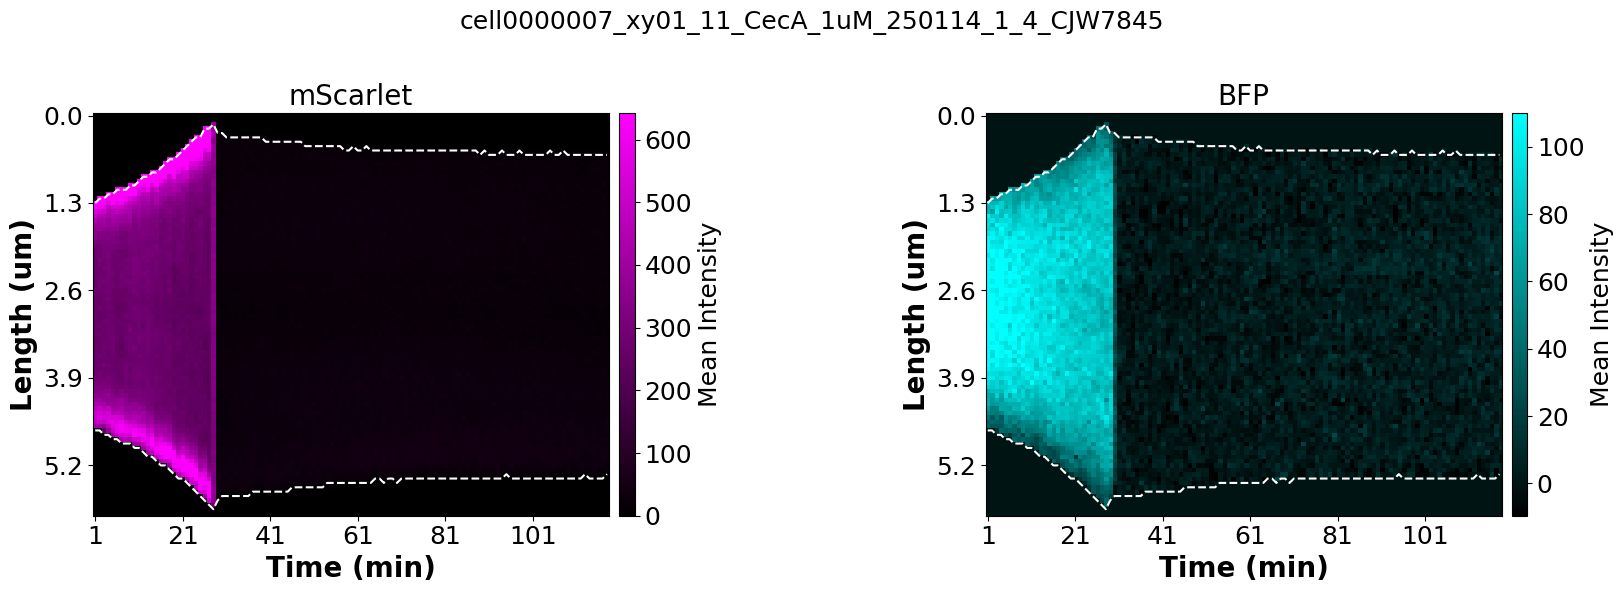

cell0000013_xy01_11_CecA_1uM_250114_1_4_CJW7845
Exporting kymo for cell0000013_xy01_11_CecA_1uM_250114_1_4_CJW7845


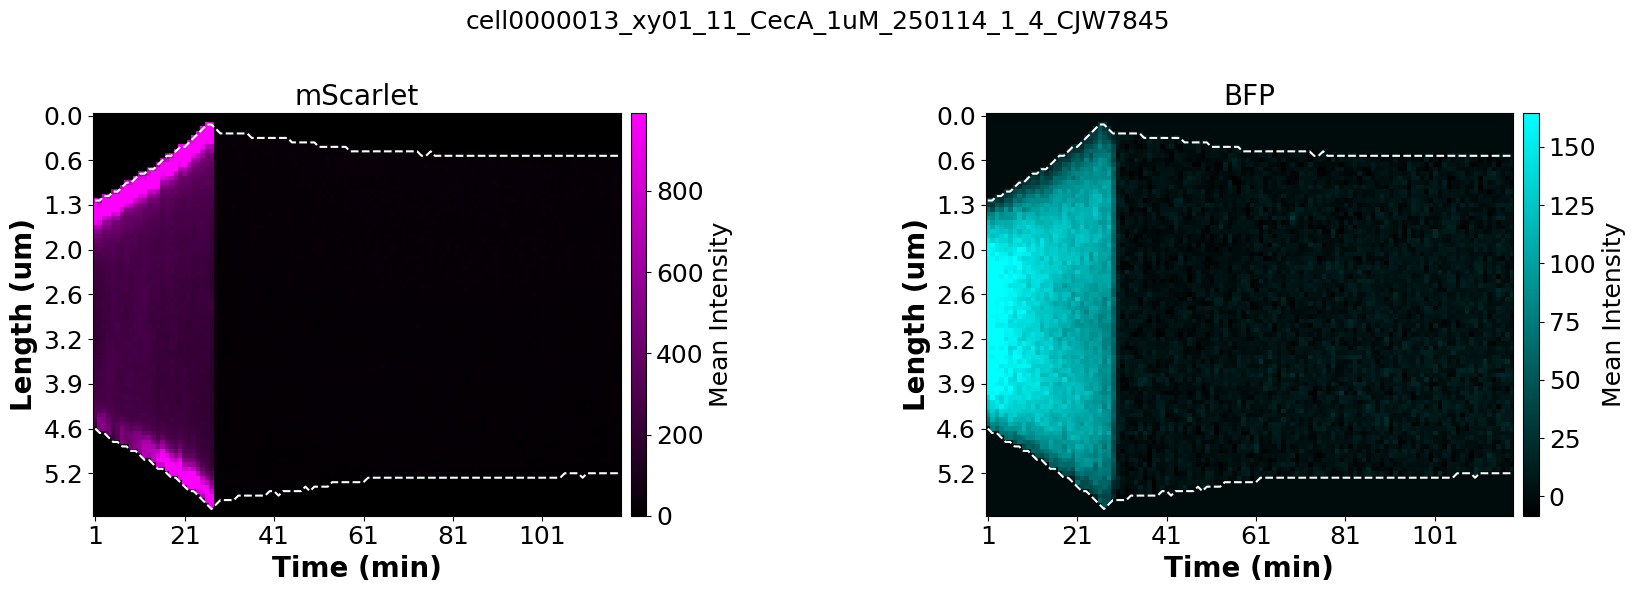

In [5]:
# --- build + plot the kymographs ---
ch_info_list = ['mScarlet','bfp','sytox_green']
build_export_kymographs_single_cell(
    experiment_path, exp_name, ch_info_list=ch_info_list,
    ft=18, bin_size_l=0.065, save=True, show_=True)